# 03 — EDA

Análisis exploratorio del corpus de minutas FOMC etiquetado. El objetivo es caracterizar el dataset antes de modelar y justificar las decisiones metodológicas (split cronológico, F1-macro como métrica, importancia de los embeddings contextuales).

**Input:** `data/processed/fomc_dataset.csv`

**Outputs:** figuras en `reports/figures/`

In [1]:
import pandas as pd
import numpy as np
import string
from pathlib import Path
from collections import Counter

import matplotlib.pyplot as plt
import seaborn as sns
import requests

from sklearn.feature_extraction.text import TfidfVectorizer
from IPython.display import display

sns.set_theme(style='whitegrid', palette='Set2')
pd.options.display.max_colwidth = 300

# Rutas
BASE_DIR     = Path('..').resolve()
DATA_RAW     = BASE_DIR / 'data' / 'raw'
LEXICONS_DIR = DATA_RAW / 'lexicons'
DATA_PROCESSED = BASE_DIR / 'data' / 'processed'
REPORTS_DIR  = BASE_DIR / 'reports' / 'figures'

LEXICONS_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

def save_fig(name):
    plt.savefig(REPORTS_DIR / name, dpi=120, bbox_inches='tight')

# Cargar dataset
df = pd.read_csv(DATA_PROCESSED / 'fomc_dataset.csv', parse_dates=['date'])
df['year']  = df['date'].dt.year
df['epoch'] = df['year'].apply(lambda y: 'pre-2005' if y < 2005 else 'post-2005')

LABEL_ORDER = ['hike', 'cut', 'hold']
SPLIT_ORDER = ['train', 'val', 'test']

print(f'Dataset: {df.shape}')
print(df['label'].value_counts())
print(df['split'].value_counts())

Dataset: (209, 6)
label
hold    141
hike     40
cut      28
Name: count, dtype: int64
split
train    145
val       32
test      32
Name: count, dtype: int64


## 1. Distribución de clases

La clase `hold` domina el dataset, reflejando los largos períodos de estabilidad monetaria (2009–2015 y 2020–2021). Esto implica que un clasificador trivial (predice siempre `hold`) ya obtiene una accuracy razonable — la métrica relevante para este problema es **F1-macro**, que penaliza el desbalance de clases. También reportamos la accuracy del clasificador trivial como cota inferior para los experimentos.

split,test,train,val,All
label,,,,
cut,6,18,4,28
hike,11,25,4,40
hold,15,102,24,141
All,32,145,32,209


Clase mayoritaria (train): hold
Accuracy trivial (majority class): 67.46%
-> F1-macro es la metrica principal para superar este baseline.


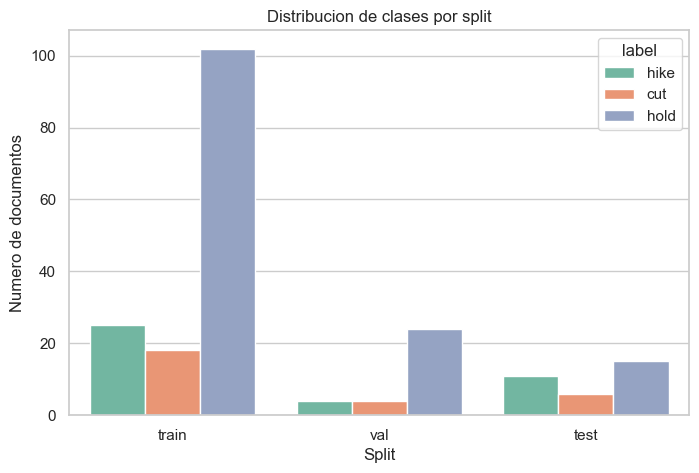

In [2]:
# Tabla de distribución por clase y split
tabla = pd.crosstab(df['label'], df['split'], margins=True)
display(tabla)

# Baseline trivial: clase mayoritaria
most_freq    = df.loc[df['split'] == 'train', 'label'].mode()[0]
acc_trivial  = (df['label'] == most_freq).mean()
print(f'Clase mayoritaria (train): {most_freq}')
print(f'Accuracy trivial (majority class): {acc_trivial:.2%}')
print('-> F1-macro es la metrica principal para superar este baseline.')

# Barplot
fig, ax = plt.subplots(figsize=(8, 5))
plot_df = df.groupby(['split', 'label']).size().reset_index(name='count')
sns.barplot(data=plot_df, x='split', y='count', hue='label',
            order=SPLIT_ORDER, hue_order=LABEL_ORDER, ax=ax)
ax.set_title('Distribucion de clases por split')
ax.set_xlabel('Split')
ax.set_ylabel('Numero de documentos')
save_fig('03_class_distribution.png')
plt.show()

## 2. Longitud de documentos

A partir de 2005 el FOMC comenzó a publicar transcripciones con mayor detalle de debate, lo que produjo minutas significativamente más largas. Esto tiene dos consecuencias para el modelado:
- **TF-IDF**: vocabulario más rico post-2005, posible sesgo léxico entre regímenes.
- **FinBERT**: límite de 512 tokens → truncación significativa en documentos largos. Documentamos qué fracción del corpus supera ese umbral.

Palabras por documento — por clase:


,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
cut,28,4060,1332,2485,2846,3884,4750,7453
hike,40,3720,1272,1946,2404,4244,4927,5465
hold,141,4489,1386,1934,3990,4482,5094,8173



Palabras por documento — por epoca:


,count,mean,std,min,25%,50%,75%,max
epoch,,,,,,,,
post-2005,169,4654,1241,1946,4094,4586,5181,8173
pre-2005,40,2725,732,1934,2304,2491,2790,4988



% docs > 512 palabras (proxy truncado FinBERT):
  Total corpus : 100%
  post-2005    : 100%


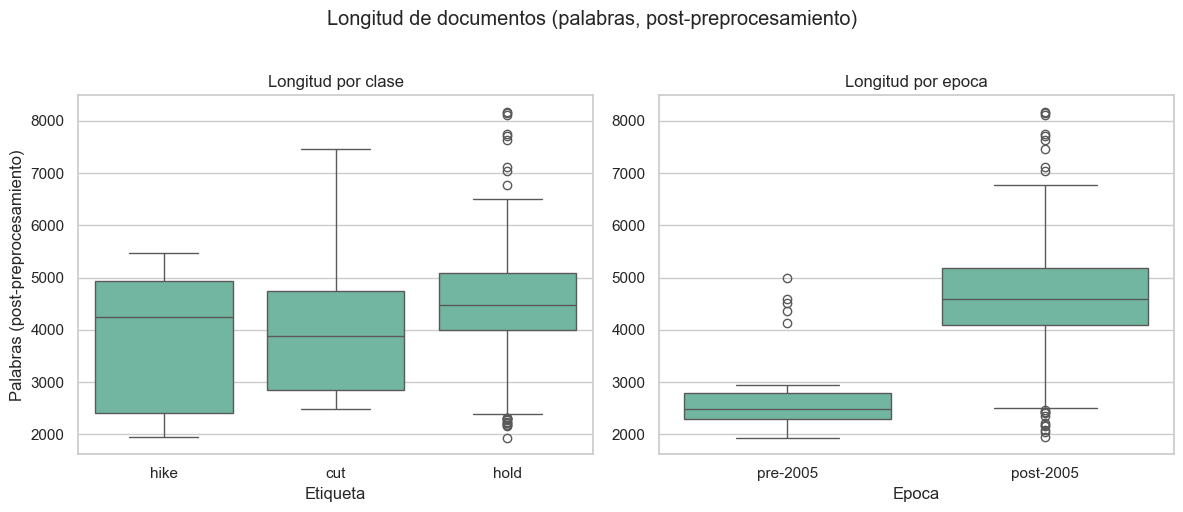

In [3]:
df['n_words'] = df['text'].str.split().str.len()

# Estadísticas descriptivas
print('Palabras por documento — por clase:')
display(df.groupby('label')['n_words'].describe().round(0).astype(int))
print()
print('Palabras por documento — por epoca:')
display(df.groupby('epoch')['n_words'].describe().round(0).astype(int))

# Fraccion de docs > 512 palabras (proxy truncado FinBERT)
pct_all  = (df['n_words'] > 512).mean()
pct_post = (df.loc[df['epoch'] == 'post-2005', 'n_words'] > 512).mean()
print(f'\n% docs > 512 palabras (proxy truncado FinBERT):')
print(f'  Total corpus : {pct_all:.0%}')
print(f'  post-2005    : {pct_post:.0%}')

# Boxplots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(data=df, x='label', y='n_words', order=LABEL_ORDER, ax=axes[0])
axes[0].set_title('Longitud por clase')
axes[0].set_xlabel('Etiqueta')
axes[0].set_ylabel('Palabras (post-preprocesamiento)')

sns.boxplot(data=df, x='epoch', y='n_words', order=['pre-2005', 'post-2005'], ax=axes[1])
axes[1].set_title('Longitud por epoca')
axes[1].set_xlabel('Epoca')
axes[1].set_ylabel('')

plt.suptitle('Longitud de documentos (palabras, post-preprocesamiento)', y=1.02)
plt.tight_layout()
save_fig('03_doc_length_boxplot.png')
plt.show()

## 3. Vocabulario por clase

Analizamos el vocabulario discriminativo de dos formas:
1. **Frecuencia bruta**: palabras más comunes por clase (stopwords y términos de dominio ya removidos).
2. **TF-IDF discriminativo**: score TF-IDF promedio por clase sobre el conjunto train — penaliza palabras que aparecen en todas las clases y resalta las específicas de cada una.

Si `hike` y `cut` muestran vocabulario claramente diferenciado de `hold`, TF-IDF + LR (experimento 1) debería capturar señal léxica. Si el overlap es alto, los métodos de embeddings contextuales serán necesarios.

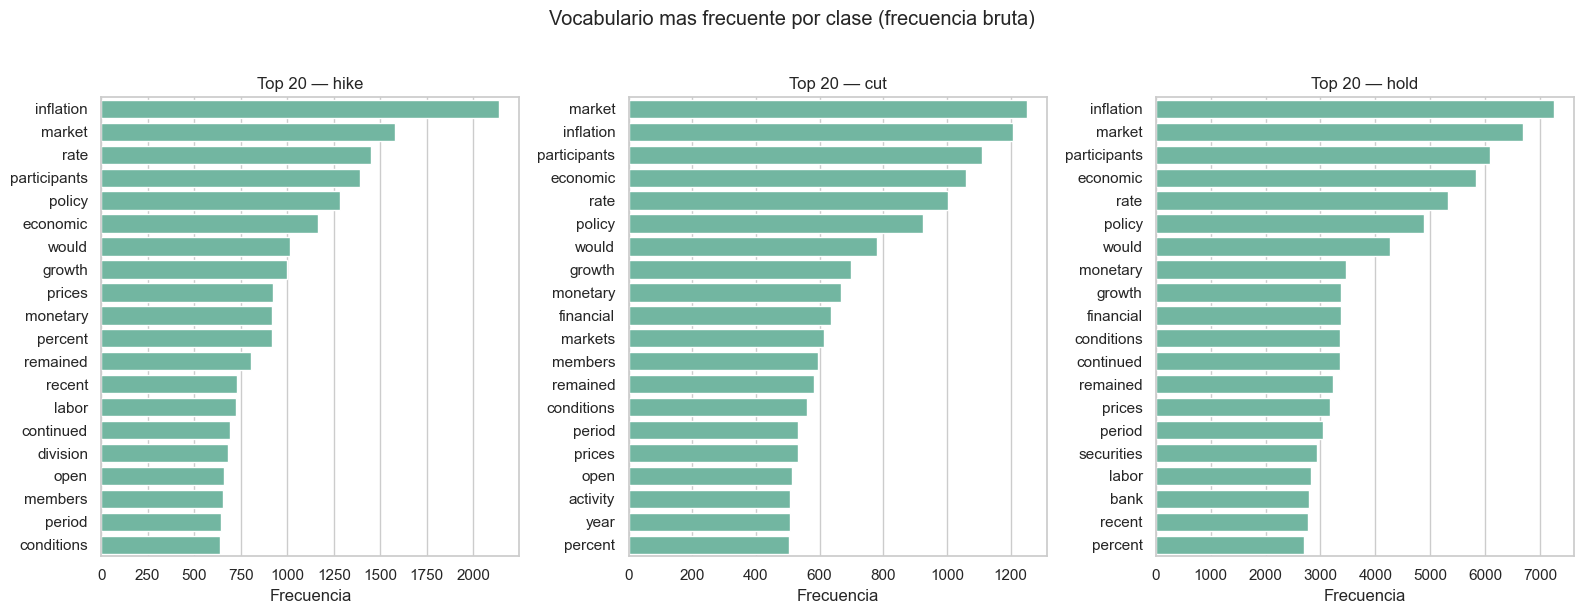

In [4]:
TOP_N = 20

fig, axes = plt.subplots(1, 3, figsize=(16, 6))
for ax, label in zip(axes, LABEL_ORDER):
    tokens = []
    for doc in df.loc[df['label'] == label, 'text']:
        tokens.extend(str(doc).split())
    top = Counter(tokens).most_common(TOP_N)
    words, freqs = zip(*top)
    sns.barplot(x=list(freqs), y=list(words), ax=ax, orient='h')
    ax.set_title(f'Top {TOP_N} — {label}')
    ax.set_xlabel('Frecuencia')
    ax.set_ylabel('')

plt.suptitle('Vocabulario mas frecuente por clase (frecuencia bruta)', y=1.02)
plt.tight_layout()
save_fig('03_top20_vocab_per_class.png')
plt.show()

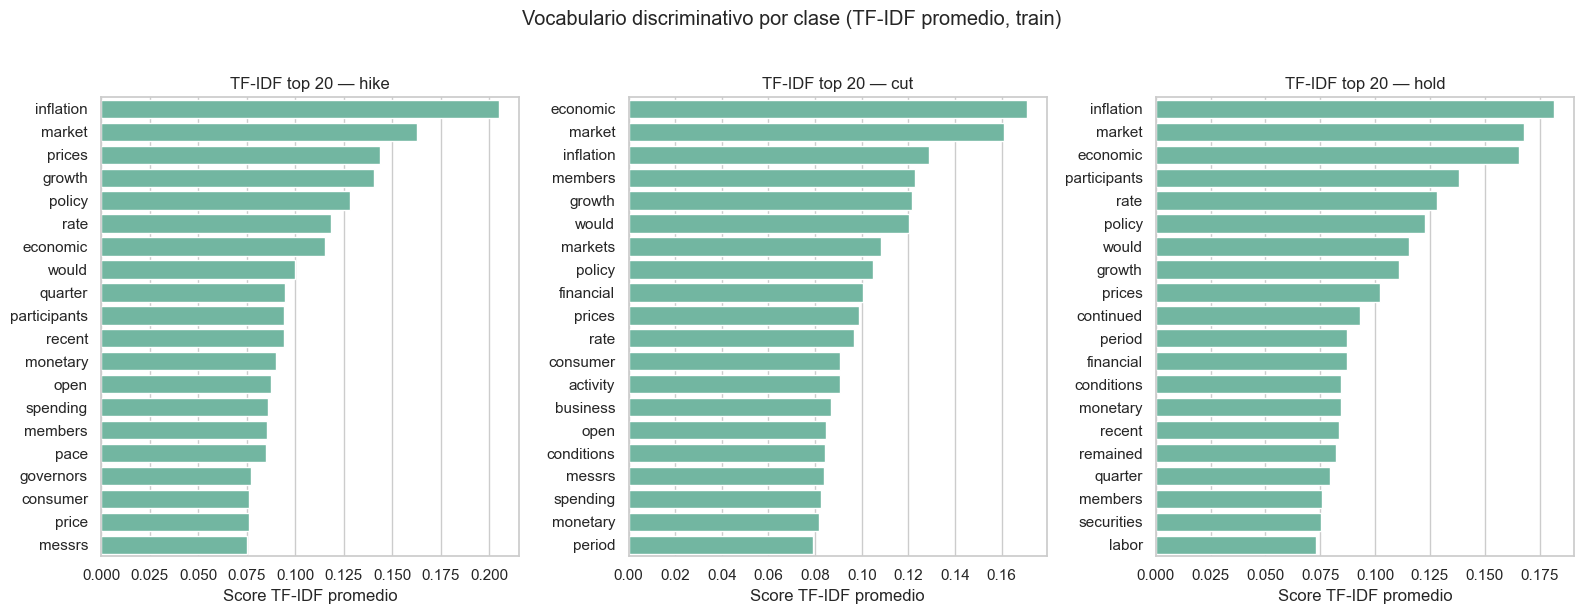

In [5]:
# TF-IDF discriminativo sobre train
train_mask   = df['split'] == 'train'
train_labels = df.loc[train_mask, 'label'].values

tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 1))
X_train = tfidf.fit_transform(df.loc[train_mask, 'text'])
feature_names = tfidf.get_feature_names_out()

fig, axes = plt.subplots(1, 3, figsize=(16, 6))
for ax, label in zip(axes, LABEL_ORDER):
    mask_label  = train_labels == label
    mean_scores = np.asarray(X_train[mask_label].mean(axis=0)).ravel()
    top_idx     = mean_scores.argsort()[-TOP_N:][::-1]
    top_words   = feature_names[top_idx]
    top_scores  = mean_scores[top_idx]
    sns.barplot(x=top_scores, y=top_words, ax=ax, orient='h')
    ax.set_title(f'TF-IDF top {TOP_N} — {label}')
    ax.set_xlabel('Score TF-IDF promedio')
    ax.set_ylabel('')

plt.suptitle('Vocabulario discriminativo por clase (TF-IDF promedio, train)', y=1.02)
plt.tight_layout()
save_fig('03_tfidf_top20_per_class.png')
plt.show()

## 4. Drift temporal

Analizamos el drift en dos dimensiones:
1. **Drift de etiquetas**: distribución de `hike`/`cut`/`hold` por año — permite ver los regímenes monetarios históricos.
2. **Drift de vocabulario**: comparamos el top-200 de palabras pre-2005 vs post-2005 con similitud de Jaccard. Un Jaccard bajo justifica el split cronológico fijo: un split aleatorio mezclaría regímenes y vocabulario, inflando las métricas de evaluación.

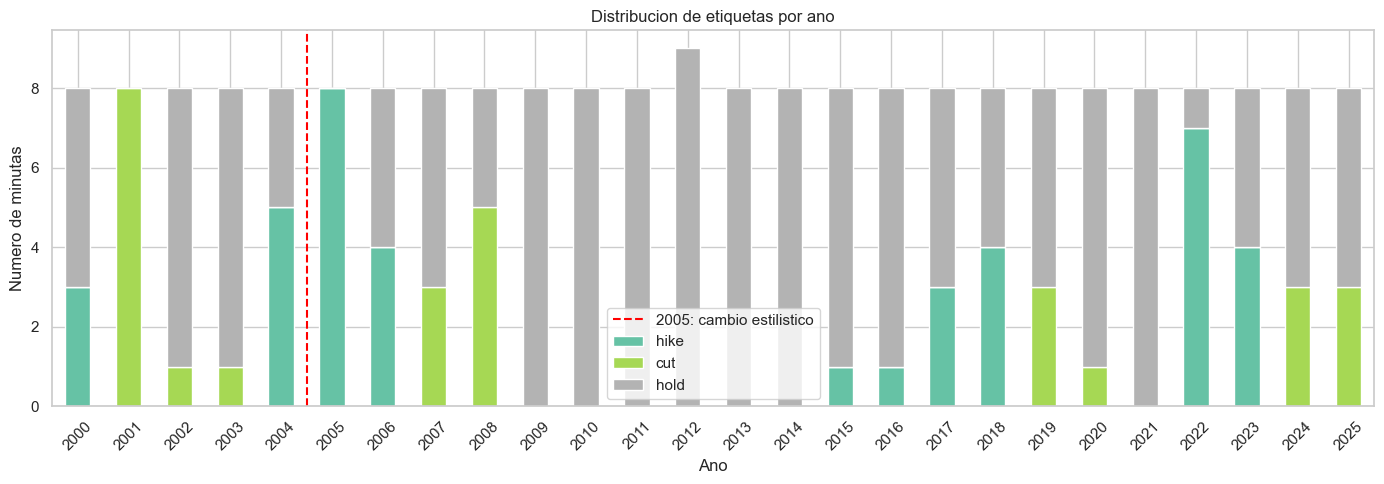

In [6]:
# Drift de etiquetas por año
pivot_labels = pd.crosstab(df['year'], df['label'])

fig, ax = plt.subplots(figsize=(14, 5))
cols_order = [c for c in LABEL_ORDER if c in pivot_labels.columns]
pivot_labels[cols_order].plot.bar(stacked=True, ax=ax, colormap='Set2')

years_list = list(pivot_labels.index)
if 2005 in years_list:
    pos_2005 = years_list.index(2005) - 0.5
    ax.axvline(x=pos_2005, color='red', linestyle='--', linewidth=1.5, label='2005: cambio estilistico')
    ax.legend()

ax.set_title('Distribucion de etiquetas por ano')
ax.set_xlabel('Ano')
ax.set_ylabel('Numero de minutas')
plt.xticks(rotation=45)
plt.tight_layout()
save_fig('03_temporal_drift_labels.png')
plt.show()

Jaccard similarity (top-200, pre vs post-2005): 0.533
  Solo pre-2005 : 61 palabras
  Compartidas   : 139 palabras
  Solo post-2005: 61 palabras
Muestra exclusivas pre-2005 : ['action', 'aggregate', 'ahead', 'anecdotal', 'august', 'available', 'basis', 'capital', 'chairman', 'confidence']
Muestra exclusivas post-2005: ['agency', 'although', 'appropriate', 'april', 'asset', 'associate', 'billion', 'changed', 'changes', 'continue']


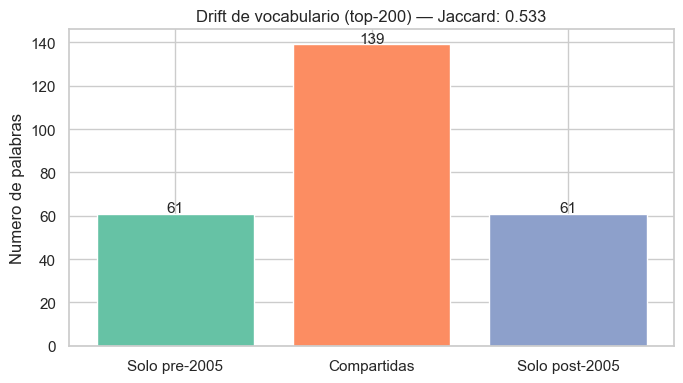

In [7]:
# Drift de vocabulario: top-200 pre vs post-2005
def top_vocab(docs, n=200):
    tokens = []
    for doc in docs:
        tokens.extend(str(doc).split())
    return set([w for w, _ in Counter(tokens).most_common(n)])

vocab_pre  = top_vocab(df.loc[df['epoch'] == 'pre-2005',  'text'])
vocab_post = top_vocab(df.loc[df['epoch'] == 'post-2005', 'text'])

only_pre  = vocab_pre  - vocab_post
only_post = vocab_post - vocab_pre
shared    = vocab_pre  & vocab_post
jaccard   = len(shared) / len(vocab_pre | vocab_post)

print(f'Jaccard similarity (top-200, pre vs post-2005): {jaccard:.3f}')
print(f'  Solo pre-2005 : {len(only_pre)} palabras')
print(f'  Compartidas   : {len(shared)} palabras')
print(f'  Solo post-2005: {len(only_post)} palabras')
print(f'Muestra exclusivas pre-2005 : {sorted(list(only_pre))[:10]}')
print(f'Muestra exclusivas post-2005: {sorted(list(only_post))[:10]}')

fig, ax = plt.subplots(figsize=(7, 4))
sizes      = [len(only_pre), len(shared), len(only_post)]
labels_bar = ['Solo pre-2005', 'Compartidas', 'Solo post-2005']
colors     = ['#66c2a5', '#fc8d62', '#8da0cb']
ax.bar(labels_bar, sizes, color=colors)
ax.set_title(f'Drift de vocabulario (top-200) — Jaccard: {jaccard:.3f}')
ax.set_ylabel('Numero de palabras')
for i, v in enumerate(sizes):
    ax.text(i, v + 0.5, str(v), ha='center', fontsize=11)
plt.tight_layout()
save_fig('03_temporal_drift_vocab.png')
plt.show()

## 5. Análisis Loughran-McDonald

El lexicón Loughran-McDonald (LM) es el estándar para análisis de sentimiento en textos financieros. Usamos las **seis categorías** que después alimentan el Experimento 2:
- **Positive / Negative**: polaridad de sentimiento
- **Uncertainty**: lenguaje hedging y vaguedad
- **Litigious**: términos legales y de responsabilidad
- **Strong Modal / Weak Modal**: fuerza de los verbos modales (certeza vs posibilidad)

Calculamos el score de cada categoría como la fracción de tokens del documento que pertenecen al conjunto. En el Master Dictionary el valor de cada columna es el año en que la palabra entró a la categoría; filtramos con `> 0` (un valor negativo indica que fue eliminada ese año). Analizamos los scores promedio por clase y por época.

Hipótesis intuitiva: `Negative` debería ser más alto en minutas `cut`. Si se confirma, esto motiva el experimento 2 (LM lexicón + LR).

In [8]:
# Lexicón local (mismo archivo que el Exp 2; sin descargas)
LM_PATH = LEXICONS_DIR / 'Loughran-McDonald_MasterDictionary_1993-2025.csv'
if not LM_PATH.exists():
    LM_PATH = LEXICONS_DIR / 'LM_MasterDictionary.csv'  # fallback
lm_df = pd.read_csv(LM_PATH)
LM_AVAILABLE = True
print('Lexicón:', LM_PATH.name, '|', len(lm_df), 'palabras')

Lexicón: Loughran-McDonald_MasterDictionary_1993-2025.csv | 86553 palabras


Tamaño de cada conjunto LM (palabras vigentes):
  Positive     :   347 palabras
  Negative     :  2345 palabras
  Uncertainty  :   297 palabras
  Litigious    :   903 palabras
  Strong_Modal :    19 palabras
  Weak_Modal   :    27 palabras



Score LM promedio por clase:


,Positive,Negative,Uncertainty,Litigious,Strong_Modal,Weak_Modal
label,,,,,,
hike,0.0171,0.0250,0.0277,0.0033,0.0007,0.0130
cut,0.0147,0.0407,0.0284,0.0037,0.0009,0.0121
hold,0.0175,0.0300,0.0274,0.0037,0.0008,0.0128


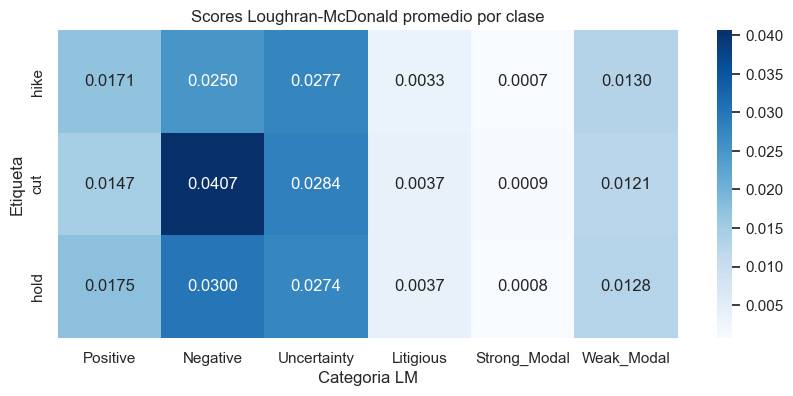

In [9]:
# 6 categorías del spec (mismas que el Exp 2). Filtro `> 0`: en el Master Dictionary el valor de
# cada columna es el año en que la palabra entró a la categoría; un valor negativo = eliminada.
LM_CATEGORIES = ['Positive', 'Negative', 'Uncertainty', 'Litigious', 'Strong_Modal', 'Weak_Modal']
lm_sets = {cat: set(lm_df.loc[lm_df[cat] > 0, 'Word'].dropna().str.lower()) for cat in LM_CATEGORIES}

print('Tamaño de cada conjunto LM (palabras vigentes):')
for cat, words in lm_sets.items():
    print(f'  {cat:13s}: {len(words):>5} palabras')

def lm_score(text, word_set):
    tokens = str(text).split()
    if not tokens:
        return 0.0
    return sum(1 for t in tokens if t in word_set) / len(tokens)

lm_cols = [f'lm_{c.lower()}' for c in LM_CATEGORIES]
for cat, col in zip(LM_CATEGORIES, lm_cols):
    df[col] = df['text'].apply(lambda t, s=lm_sets[cat]: lm_score(t, s))

scores_label = df.groupby('label')[lm_cols].mean()
scores_label.columns = LM_CATEGORIES
print('\nScore LM promedio por clase:')
display(scores_label.loc[LABEL_ORDER].round(4))

fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(scores_label.loc[LABEL_ORDER], annot=True, fmt='.4f', cmap='Blues', ax=ax)
ax.set_title('Scores Loughran-McDonald promedio por clase')
ax.set_xlabel('Categoria LM')
ax.set_ylabel('Etiqueta')
save_fig('03_lm_scores_per_class.png')
plt.show()

Score LM promedio por epoca:


,Positive,Negative,Uncertainty,Litigious,Strong_Modal,Weak_Modal
epoch,,,,,,
post-2005,0.0162,0.0296,0.0272,0.0036,0.0008,0.0125
pre-2005,0.0207,0.0341,0.0295,0.0039,0.0010,0.0138


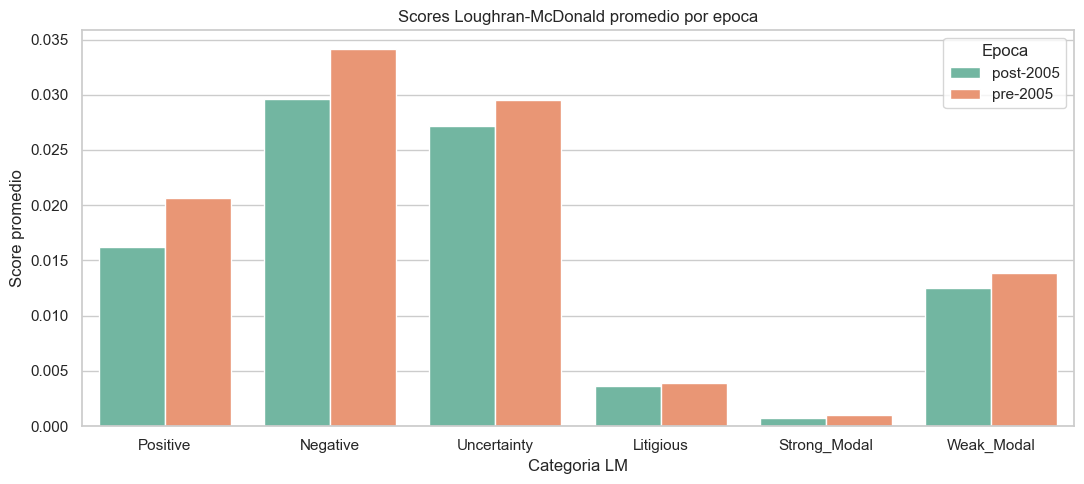

In [10]:
if not LM_AVAILABLE:
    print('Lexicon LM no disponible — omitiendo analisis por epoca.')
else:
    scores_epoch = df.groupby('epoch')[lm_cols].mean()
    scores_epoch.columns = LM_CATEGORIES
    print('Score LM promedio por epoca:')
    display(scores_epoch.round(4))

    scores_melt = (
        scores_epoch.T
        .reset_index()
        .rename(columns={'index': 'Categoria'})
        .melt(id_vars='Categoria', var_name='Epoca', value_name='Score')
    )

    fig, ax = plt.subplots(figsize=(11, 5))
    sns.barplot(data=scores_melt, x='Categoria', y='Score', hue='Epoca', ax=ax)
    ax.set_title('Scores Loughran-McDonald promedio por epoca')
    ax.set_xlabel('Categoria LM')
    ax.set_ylabel('Score promedio')
    plt.tight_layout()
    save_fig('03_lm_scores_per_epoch.png')
    plt.show()